In [2]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
from scipy import stats

/glade/u/home/acruz/.conda/envs/Caribe_Heat_AN_2026/lib/python3.14/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [3]:
ERA5_path = '/glade/work/acruz/Caribbean_Heat_data/ERA5/'
OISST_path= '/glade/work/acruz/Caribbean_Heat_data/OISST/'
HI_dmax = xr.open_dataset(ERA5_path+'dailymax_HI.nc')
ATL3 = xr.open_dataset(OISST_path+'ATL3.nc')
ONI = xr.open_dataset(OISST_path+'ONI.nc')
CANI_EANI = xr.open_dataset(OISST_path+'CANI_EANI_OISST.nc')
HI_dmax_month_anom = xr.open_dataset(ERA5_path+'HI_dmax_month_anom.nc')

/glade/u/home/acruz/.conda/envs/Caribe_Heat_AN_2026/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
RH = xr.open_dataset(ERA5_path+'RHanom_during_HIdmax.nc')
T  = xr.open_dataset(ERA5_path+'Tanom_during_HIdmax.nc')
U  = xr.open_dataset(ERA5_path+'U_Hidmax_anom.nc')
V  = xr.open_dataset(ERA5_path+'V_Hidmax_anom.nc')

In [5]:
idate = '1981-09-30'
fdate = '2026-02-28'
HI_dmax = HI_dmax['HI_daily_max'].sel(time=slice(idate, fdate))
ATL3 = ATL3['ATL3_OISST'].sel(time=slice(idate, fdate))
ONI = ONI['ONI_OISST'].sel(time=slice(idate, fdate))
HI_dmax_month_anom = HI_dmax_month_anom['HI_dmax_anom'].sel(time=slice(idate, fdate))
RH = RH['RHanom_during_HIdmax'].sel(time=slice(idate, fdate))
T = T['Tanom_during_HIdmax'].sel(time=slice(idate, fdate))
U = U['U10_HIdmax_anom'].sel(time=slice(idate, fdate))
V = V['V10_HIdmax_anom'].sel(time=slice(idate, fdate))
CANI = CANI_EANI['CANI'].sel(time=slice(idate, fdate))
EANI = CANI_EANI['EANI'].sel(time=slice(idate, fdate))

In [6]:
CANI

<xarray.DataArray 'CANI' (time: 534)> Size: 4kB
[534 values with dtype=float64]
Coordinates:
  * time     (time) datetime64[ns] 4kB 1981-09-30 1981-10-31 ... 2026-02-28
Attributes:
    description:  Central Atlantic Niño Index. PCs scaled by STD. Rolling mea...

In [7]:
#  mix u and v to a single dataset
UV = xr.merge([U, V], compat='equals')
UV

<xarray.Dataset> Size: 1GB
Dimensions:          (latitude: 82, longitude: 121, time: 16164)
Coordinates:
  * latitude         (latitude) float64 656B 7.75 8.0 8.25 ... 27.5 27.75 28.0
  * longitude        (longitude) float64 968B -89.0 -88.75 ... -59.25 -59.0
  * time             (time) datetime64[ns] 129kB 1981-09-30 ... 2025-12-31
    month            (time) int64 129kB 9 10 10 10 10 10 ... 12 12 12 12 12 12
Data variables:
    U10_HIdmax_anom  (time, latitude, longitude) float32 642MB ...
    V10_HIdmax_anom  (time, latitude, longitude) float32 642MB ...

# monthly means

In [8]:
def me_mean(ds):
    meds = ds.resample(time='ME').mean()
    return meds


meHI_dmax = me_mean(HI_dmax)
meRH = me_mean(RH)
meT = me_mean(T)
meUV = me_mean(UV)

# LRS selection

In [9]:
LRS = [8, 9, 10, 11]
LRS_HI_dmax_anom = HI_dmax_month_anom.where(HI_dmax_month_anom.time.dt.month.isin(LRS), drop=True)
LRS_ATL3 = ATL3.where(ATL3.time.dt.month.isin(LRS), drop=True)
LRS_ONI = ONI.where(ONI.time.dt.month.isin(LRS), drop=True)
LRS_RH = meRH.where(meRH.time.dt.month.isin(LRS), drop=True)
LRS_T = meT.where(meT.time.dt.month.isin(LRS), drop=True)
LRS_UV = meUV.where(meUV.time.dt.month.isin(LRS), drop=True)
LRS_CANI = CANI.where(CANI.time.dt.month.isin(LRS), drop=True)
LRS_EANI = EANI.where(EANI.time.dt.month.isin(LRS), drop=True)

# phase selection

In [10]:
def niño(ds):
    return ds >= 0.5


def niña(ds):
    return ds <= -0.5


def neutral(ds):
    return ((ds > -0.5) & (ds < 0.5) )

In [11]:
# o in the end is for niño, a is for niña, n for neutral
CANo = LRS_CANI.time.dt.year.where(niño(LRS_CANI), drop=True).rename('Warm CAN')
CANa = LRS_CANI.time.dt.year.where(niña(LRS_CANI), drop=True).rename('Cold CAN')
CANn = LRS_CANI.time.dt.year.where(neutral(LRS_CANI), drop=True).rename('Neutral CAN')

EANo = LRS_EANI.time.dt.year.where(niño(LRS_EANI), drop=True).rename('Warm EAN')
EANa = LRS_EANI.time.dt.year.where(niña(LRS_EANI), drop=True).rename('Cold EAN')
EANn = LRS_EANI.time.dt.year.where(neutral(LRS_EANI), drop=True).rename('Neutral EAN')

ATL3a= LRS_ATL3.time.dt.year.where(niña(LRS_ATL3), drop=True).rename('Cold ATL3')
ATL3o= LRS_ATL3.time.dt.year.where(niño(LRS_ATL3), drop=True).rename('Warm ATL3')
ATL3n= LRS_ATL3.time.dt.year.where(neutral(LRS_ATL3), drop=True).rename('Neutral ATL3')

ONIo = LRS_ONI.time.dt.year.where(niño(LRS_ONI), drop=True).rename('Warm ONI')
ONIa = LRS_ONI.time.dt.year.where(niña(LRS_ONI), drop=True).rename('Cold ONI')
ONIn = LRS_ONI.time.dt.year.where(neutral(LRS_ONI), drop=True).rename('Neutral ONI')

# idx season mean every year

In [12]:
LRS_CANI_y = LRS_CANI.resample(time='YE').mean()
LRS_EANI_y = LRS_EANI.resample(time='YE').mean()
LRS_ATL3_y = LRS_ATL3.resample(time='YE').mean()
LRS_ONI_y = LRS_ONI.resample(time='YE').mean()

### lists

#### Atlantic Niño years

In [13]:
CANo

<xarray.DataArray 'Warm CAN' (time: 42)> Size: 336B
array([1993., 2003., 2003., 2006., 2007., 2007., 2008., 2008., 2008.,
       2010., 2010., 2010., 2015., 2016., 2016., 2016., 2017., 2017.,
       2017., 2018., 2018., 2018., 2018., 2019., 2020., 2020., 2021.,
       2021., 2021., 2021., 2022., 2022., 2022., 2022., 2023., 2023.,
       2023., 2023., 2024., 2024., 2025., 2025.])
Coordinates:
  * time     (time) datetime64[ns] 336B 1993-11-30 2003-10-31 ... 2025-11-30

In [14]:
EANo

<xarray.DataArray 'Warm EAN' (time: 66)> Size: 528B
array([1984., 1984., 1987., 1998., 1998., 1999., 2003., 2003., 2003.,
       2003., 2004., 2004., 2005., 2006., 2006., 2007., 2007., 2008.,
       2008., 2008., 2008., 2009., 2010., 2010., 2010., 2012., 2012.,
       2014., 2015., 2015., 2016., 2016., 2016., 2016., 2017., 2017.,
       2017., 2017., 2018., 2018., 2018., 2019., 2019., 2019., 2019.,
       2020., 2020., 2020., 2020., 2021., 2021., 2021., 2021., 2022.,
       2022., 2022., 2022., 2023., 2023., 2023., 2023., 2024., 2024.,
       2024., 2024., 2025.])
Coordinates:
  * time     (time) datetime64[ns] 528B 1984-08-31 1984-09-30 ... 2025-10-31

In [15]:
ATL3o

<xarray.DataArray 'Warm ATL3' (time: 39)> Size: 312B
array([1984., 1984., 1987., 1987., 1988., 1988., 1993., 1999., 1999.,
       2007., 2007., 2007., 2008., 2008., 2010., 2010., 2016., 2016.,
       2016., 2016., 2017., 2018., 2018., 2018., 2018., 2019., 2019.,
       2021., 2021., 2021., 2021., 2022., 2022., 2023., 2023., 2023.,
       2023., 2024., 2024.])
Coordinates:
  * time     (time) datetime64[ns] 312B 1984-09-30 1984-10-31 ... 2024-11-30
Attributes:
    long_name:  Center time of the day

#### Atlantic Niña years

In [16]:
CANa

<xarray.DataArray 'Cold CAN' (time: 61)> Size: 488B
array([1981., 1982., 1982., 1982., 1982., 1983., 1983., 1983., 1983.,
       1985., 1985., 1985., 1985., 1986., 1986., 1986., 1988., 1989.,
       1990., 1990., 1990., 1991., 1991., 1991., 1991., 1992., 1992.,
       1992., 1992., 1993., 1994., 1994., 1994., 1994., 1995., 1995.,
       1995., 1996., 1996., 1996., 1997., 1997., 1998., 1999., 2000.,
       2000., 2000., 2000., 2001., 2001., 2002., 2002., 2004., 2005.,
       2009., 2009., 2012., 2012., 2013., 2014., 2019.])
Coordinates:
  * time     (time) datetime64[ns] 488B 1981-09-30 1982-08-31 ... 2019-08-31

In [17]:
EANa

<xarray.DataArray 'Cold EAN' (time: 49)> Size: 392B
array([1981., 1982., 1982., 1982., 1982., 1983., 1983., 1983., 1983.,
       1984., 1985., 1985., 1985., 1985., 1986., 1986., 1986., 1986.,
       1989., 1990., 1991., 1991., 1991., 1991., 1992., 1992., 1992.,
       1992., 1993., 1994., 1994., 1994., 1995., 1996., 1996., 1996.,
       1996., 1997., 1997., 2000., 2000., 2001., 2001., 2001., 2001.,
       2002., 2002., 2002., 2015.])
Coordinates:
  * time     (time) datetime64[ns] 392B 1981-09-30 1982-08-31 ... 2015-08-31

In [18]:
ATL3a

<xarray.DataArray 'Cold ATL3' (time: 10)> Size: 80B
array([1982., 1982., 1982., 1982., 1983., 1992., 1992., 1992., 1997.,
       2005.])
Coordinates:
  * time     (time) datetime64[ns] 80B 1982-08-31 1982-09-30 ... 2005-08-31
Attributes:
    long_name:  Center time of the day

#### ENSO years

In [19]:
ONIo

<xarray.DataArray 'Warm ONI' (time: 49)> Size: 392B
array([1982., 1982., 1982., 1982., 1986., 1987., 1987., 1987., 1987.,
       1991., 1991., 1991., 1991., 1994., 1994., 1997., 1997., 1997.,
       1997., 2002., 2002., 2002., 2002., 2004., 2004., 2004., 2004.,
       2006., 2006., 2009., 2009., 2009., 2009., 2012., 2012., 2012.,
       2012., 2014., 2015., 2015., 2015., 2015., 2018., 2018., 2019.,
       2023., 2023., 2023., 2023.])
Coordinates:
  * time     (time) datetime64[ns] 392B 1982-08-31 1982-09-30 ... 2023-11-30
Attributes:
    long_name:  Center time of the day

In [20]:
ONIa

<xarray.DataArray 'Cold ONI' (time: 44)> Size: 352B
array([1983., 1983., 1984., 1984., 1984., 1985., 1985., 1985., 1985.,
       1988., 1988., 1988., 1988., 1989., 1989., 1995., 1995., 1998.,
       1998., 1998., 1998., 1999., 1999., 1999., 1999., 2000., 2007.,
       2007., 2007., 2010., 2010., 2010., 2010., 2011., 2011., 2016.,
       2016., 2020., 2020., 2021., 2022., 2022., 2022., 2022.])
Coordinates:
  * time     (time) datetime64[ns] 352B 1983-10-31 1983-11-30 ... 2022-11-30
Attributes:
    long_name:  Center time of the day

#### Neutral

In [21]:
CANn

<xarray.DataArray 'Neutral CAN' (time: 76)> Size: 608B
array([1981., 1981., 1984., 1984., 1984., 1984., 1986., 1987., 1987.,
       1987., 1987., 1988., 1988., 1988., 1989., 1989., 1989., 1990.,
       1993., 1993., 1995., 1996., 1997., 1997., 1998., 1998., 1998.,
       1999., 1999., 1999., 2001., 2001., 2002., 2002., 2003., 2003.,
       2004., 2004., 2004., 2005., 2005., 2005., 2006., 2006., 2006.,
       2007., 2007., 2008., 2009., 2009., 2010., 2011., 2011., 2011.,
       2011., 2012., 2012., 2013., 2013., 2013., 2014., 2014., 2014.,
       2015., 2015., 2015., 2016., 2017., 2019., 2019., 2020., 2020.,
       2024., 2024., 2025., 2025.])
Coordinates:
  * time     (time) datetime64[ns] 608B 1981-10-31 1981-11-30 ... 2025-09-30

In [22]:
EANn

<xarray.DataArray 'Neutral EAN' (time: 64)> Size: 512B
array([1981., 1981., 1984., 1987., 1987., 1987., 1988., 1988., 1988.,
       1988., 1989., 1989., 1989., 1990., 1990., 1990., 1993., 1993.,
       1993., 1994., 1995., 1995., 1995., 1997., 1997., 1998., 1998.,
       1999., 1999., 1999., 2000., 2000., 2002., 2004., 2004., 2005.,
       2005., 2005., 2006., 2006., 2007., 2007., 2009., 2009., 2009.,
       2010., 2011., 2011., 2011., 2011., 2012., 2012., 2013., 2013.,
       2013., 2013., 2014., 2014., 2014., 2015., 2018., 2025., 2025.,
       2025.])
Coordinates:
  * time     (time) datetime64[ns] 512B 1981-10-31 1981-11-30 ... 2025-11-30

In [23]:
ATL3n

<xarray.DataArray 'Neutral ATL3' (time: 128)> Size: 1kB
array([1981., 1983., 1983., 1983., 1984., 1984., 1985., 1985., 1985.,
       1985., 1986., 1986., 1986., 1986., 1987., 1987., 1988., 1988.,
       1989., 1989., 1989., 1989., 1990., 1990., 1990., 1990., 1991.,
       1991., 1991., 1991., 1992., 1993., 1993., 1993., 1994., 1994.,
       1994., 1994., 1995., 1995., 1995., 1995., 1996., 1996., 1996.,
       1996., 1997., 1997., 1997., 1998., 1998., 1998., 1998., 1999.,
       1999., 2000., 2000., 2000., 2000., 2001., 2001., 2001., 2001.,
       2002., 2002., 2002., 2002., 2003., 2003., 2003., 2003., 2004.,
       2004., 2004., 2004., 2005., 2005., 2005., 2006., 2006., 2006.,
       2006., 2007., 2008., 2008., 2009., 2009., 2009., 2009., 2010.,
       2010., 2011., 2011., 2011., 2011., 2012., 2012., 2012., 2012.,
       2013., 2013., 2013., 2013., 2014., 2014., 2014., 2014., 2015.,
       2015., 2015., 2015., 2017., 2017., 2017., 2019., 2019., 2020.,
       2020., 2020., 2020., 2022., 2022., 2024., 2024., 2025., 2025.,
       2025., 2025.])
Coordinates:
  * time     (time) datetime64[ns] 1kB 1981-11-30 1983-09-30 ... 2025-11-30
Attributes:
    long_name:  Center time of the day

In [24]:
ONIn

<xarray.DataArray 'Neutral ONI' (time: 84)> Size: 672B
array([1981., 1983., 1983., 1984., 1986., 1986., 1986., 1989., 1989.,
       1990., 1990., 1990., 1990., 1992., 1992., 1992., 1992., 1993.,
       1993., 1993., 1993., 1994., 1994., 1995., 1995., 1996., 1996.,
       1996., 1996., 2000., 2000., 2000., 2001., 2001., 2001., 2001.,
       2003., 2003., 2003., 2003., 2005., 2005., 2005., 2005., 2006.,
       2006., 2007., 2008., 2008., 2008., 2008., 2011., 2011., 2013.,
       2013., 2013., 2013., 2014., 2014., 2014., 2016., 2016., 2017.,
       2017., 2017., 2017., 2018., 2018., 2019., 2019., 2019., 2020.,
       2020., 2021., 2021., 2021., 2024., 2024., 2024., 2024., 2025.,
       2025., 2025., 2025.])
Coordinates:
  * time     (time) datetime64[ns] 672B 1981-11-30 1983-08-31 ... 2025-11-30
Attributes:
    long_name:  Center time of the day

## select anomalies

In [25]:
indices = [CANo, CANn, CANa, EANo, EANn, EANa, ATL3o, ATL3n, ATL3a, ONIo, ONIn, ONIa]
LRS_HI_oan = []
LRS_RH_oan = []
LRS_T_oan = []
LRS_UV_oan = []

for i in indices:
    LRS_HI_oan.append(LRS_HI_dmax_anom.where(LRS_HI_dmax_anom.time.dt.year.isin(i.values), drop=True).rename(i.name))
    LRS_RH_oan.append(LRS_RH.where(LRS_RH.time.dt.year.isin(i.values), drop=True).rename(i.name))
    LRS_T_oan.append(LRS_T.where(LRS_T.time.dt.year.isin(i.values), drop=True).rename(i.name))
    LRS_UV_oan.append(LRS_UV.where(LRS_UV.time.dt.year.isin(i.values), drop=True).rename({'U10_HIdmax_anom': i.name+'_U', 'V10_HIdmax_anom': i.name+'_V'}))

# Significance testing

In [26]:
def xr_t_test(neutralds, anomds, dim='time'):

    stats_func = lambda x, y: stats.ttest_ind(x, y, axis=-1, equal_var=True)
    t, p = xr.apply_ufunc(stats_func, neutralds, anomds, 
                          input_core_dims=[[dim], [dim]],
                          output_core_dims=[[],[]],
                          vectorize=True, exclude_dims=set([dim])
                          )
    t_da = xr.DataArray(t, coords={'longitude': neutralds.longitude, 'latitude': neutralds.latitude}, name='t'+t.name[-3:])
    p_da = xr.DataArray(p, coords=t_da.coords, name="p"+t.name[-3:])

    stats_da = xr.merge([t_da, p_da])
    
    return stats_da

In [27]:
warms = LRS_HI_oan[0::3]
colds = LRS_HI_oan[2::3]
neutrals = LRS_HI_oan[1::3]

In [28]:
warm_stats = []
for i in range(4):
    warm_stats.append(xr_t_test(neutrals[i], warms[i]))
warm_stats

[<xarray.Dataset> Size: 81kB
 Dimensions:    (longitude: 121, latitude: 82)
 Coordinates:
   * longitude  (longitude) float64 968B -89.0 -88.75 -88.5 ... -59.25 -59.0
   * latitude   (latitude) float64 656B 7.75 8.0 8.25 8.5 ... 27.5 27.75 28.0
 Data variables:
     tCAN       (latitude, longitude) float32 40kB -2.754 -2.696 ... -3.018
     pCAN       (latitude, longitude) float32 40kB 0.006425 0.007607 ... 0.002872,
 <xarray.Dataset> Size: 81kB
 Dimensions:    (longitude: 121, latitude: 82)
 Coordinates:
   * longitude  (longitude) float64 968B -89.0 -88.75 -88.5 ... -59.25 -59.0
   * latitude   (latitude) float64 656B 7.75 8.0 8.25 8.5 ... 27.5 27.75 28.0
 Data variables:
     tEAN       (latitude, longitude) float32 40kB -2.507 -2.447 ... -3.13 -3.091
     pEAN       (latitude, longitude) float32 40kB 0.01297 0.01523 ... 0.002268,
 <xarray.Dataset> Size: 81kB
 Dimensions:    (longitude: 121, latitude: 82)
 Coordinates:
   * longitude  (longitude) float64 968B -89.0 -88.75 -88.5 ... 

In [29]:
cold_stats = []
for i in range(4):
    cold_stats.append(xr_t_test(neutrals[i], colds[i]))
cold_stats

[<xarray.Dataset> Size: 81kB
 Dimensions:    (longitude: 121, latitude: 82)
 Coordinates:
   * longitude  (longitude) float64 968B -89.0 -88.75 -88.5 ... -59.25 -59.0
   * latitude   (latitude) float64 656B 7.75 8.0 8.25 8.5 ... 27.5 27.75 28.0
 Data variables:
     tCAN       (latitude, longitude) float32 40kB 1.435 1.395 ... 2.641 2.625
     pCAN       (latitude, longitude) float32 40kB 0.1526 0.1642 ... 0.009224,
 <xarray.Dataset> Size: 81kB
 Dimensions:    (longitude: 121, latitude: 82)
 Coordinates:
   * longitude  (longitude) float64 968B -89.0 -88.75 -88.5 ... -59.25 -59.0
   * latitude   (latitude) float64 656B 7.75 8.0 8.25 8.5 ... 27.5 27.75 28.0
 Data variables:
     tEAN       (latitude, longitude) float32 40kB 1.026 1.011 ... 3.252 3.293
     pEAN       (latitude, longitude) float32 40kB 0.3061 0.3134 ... 0.001193,
 <xarray.Dataset> Size: 81kB
 Dimensions:    (longitude: 121, latitude: 82)
 Coordinates:
   * longitude  (longitude) float64 968B -89.0 -88.75 -88.5 ... -59.25

# Phase plots

## Anoms

### HI and wind

In [30]:
LRS_HI_oan_me = []
LRS_UV_oan_me = []
for i in LRS_HI_oan:
    LRS_HI_oan_me.append(i.mean('time'))
for i in LRS_UV_oan:
    LRS_UV_oan_me.append(i.mean('time'))

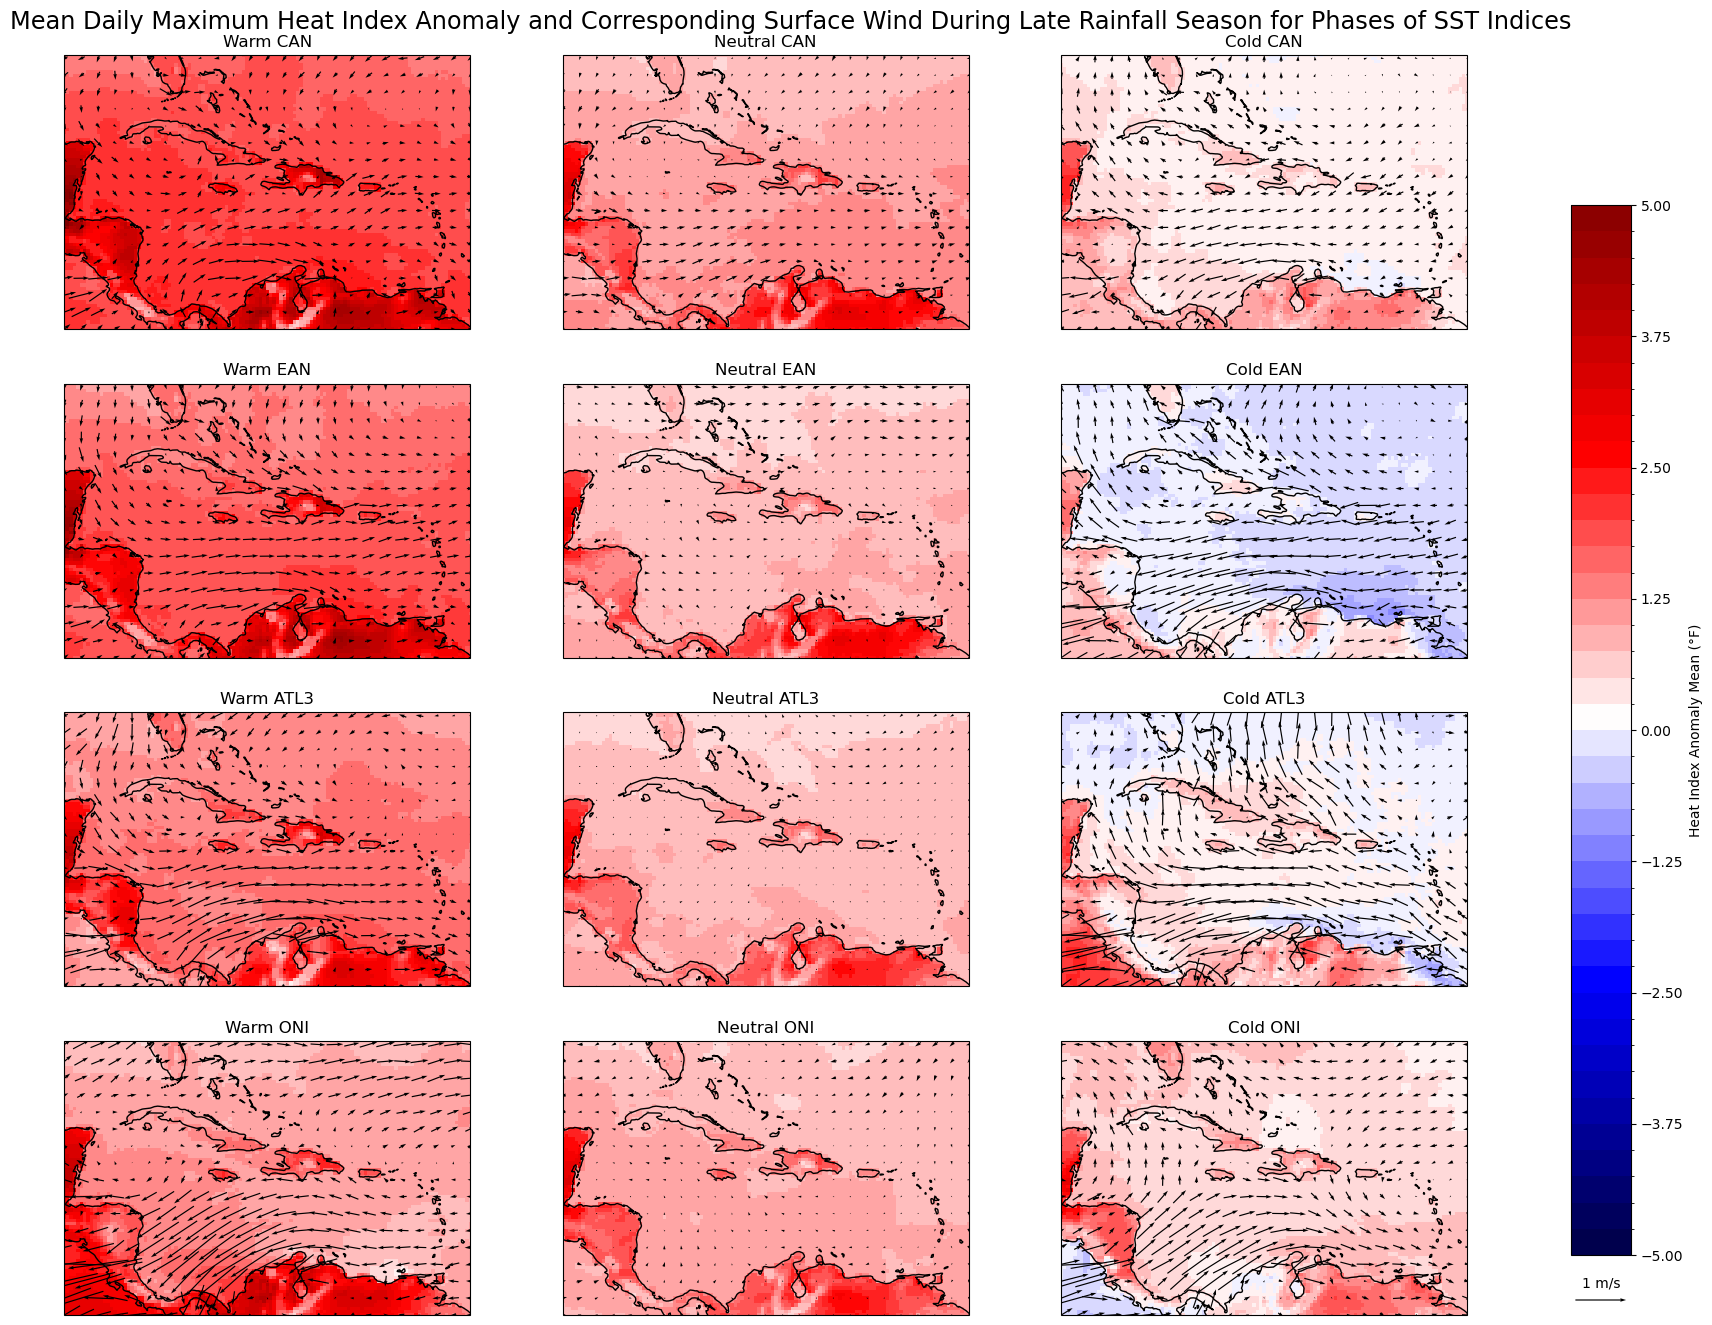

In [31]:
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(20, 15), sharex=True, sharey=True, subplot_kw={'projection': ccrs.PlateCarree()},)

flat_axes = axes.flatten()

for ax_i, (da, UVds) in enumerate(zip(LRS_HI_oan_me, LRS_UV_oan_me)):
    ax = flat_axes[ax_i]
    ax.set_extent([da.longitude.min(), da.longitude.max(), da.latitude.min(), da.latitude.max()], crs=ccrs.PlateCarree())
    
    da.plot(ax=ax, x='longitude', y='latitude', add_colorbar=False, levels=np.arange(-5, 5.25, 0.25), transform=ccrs.PlateCarree(), colors='seismic')

    U_var = [var for var in UVds.data_vars if var.endswith('U')][0]
    V_var = [var for var in UVds.data_vars if var.endswith('V')][0]

    UV_coarse = UVds.isel(longitude=slice(None, None, 5), latitude=slice(None, None, 5))
    quiver_obj = UV_coarse.plot.quiver(ax=ax, x='longitude', y='latitude', u=U_var, v=V_var, transform=ccrs.PlateCarree(), add_guide=False, scale=8)
    
    ax.set_title(da.name)
    ax.coastlines(transform=ccrs.PlateCarree())

cax = fig.add_axes([0.89, 0.15, 0.03, 0.7])
fig.colorbar(axes.flat[0].collections[0],cax=cax, label='Heat Index Anomaly Mean (°F)', orientation='vertical', extend='neither')
plt.subplots_adjust(wspace=0.1, right=0.85, top=0.95)
plt.suptitle('Mean Daily Maximum Heat Index Anomaly and Corresponding Surface Wind During Late Rainfall Season for Phases of SST Indices', fontsize='xx-large')
ax.quiverkey(quiver_obj, X=0.905, Y=0.12, U=1, label='1 m/s', labelpos='N', coordinates='figure')
plt.show()

### RH

In [115]:
LRS_RH_oan_me = []
for i in LRS_RH_oan:
    LRS_RH_oan_me.append(i.mean('time'))

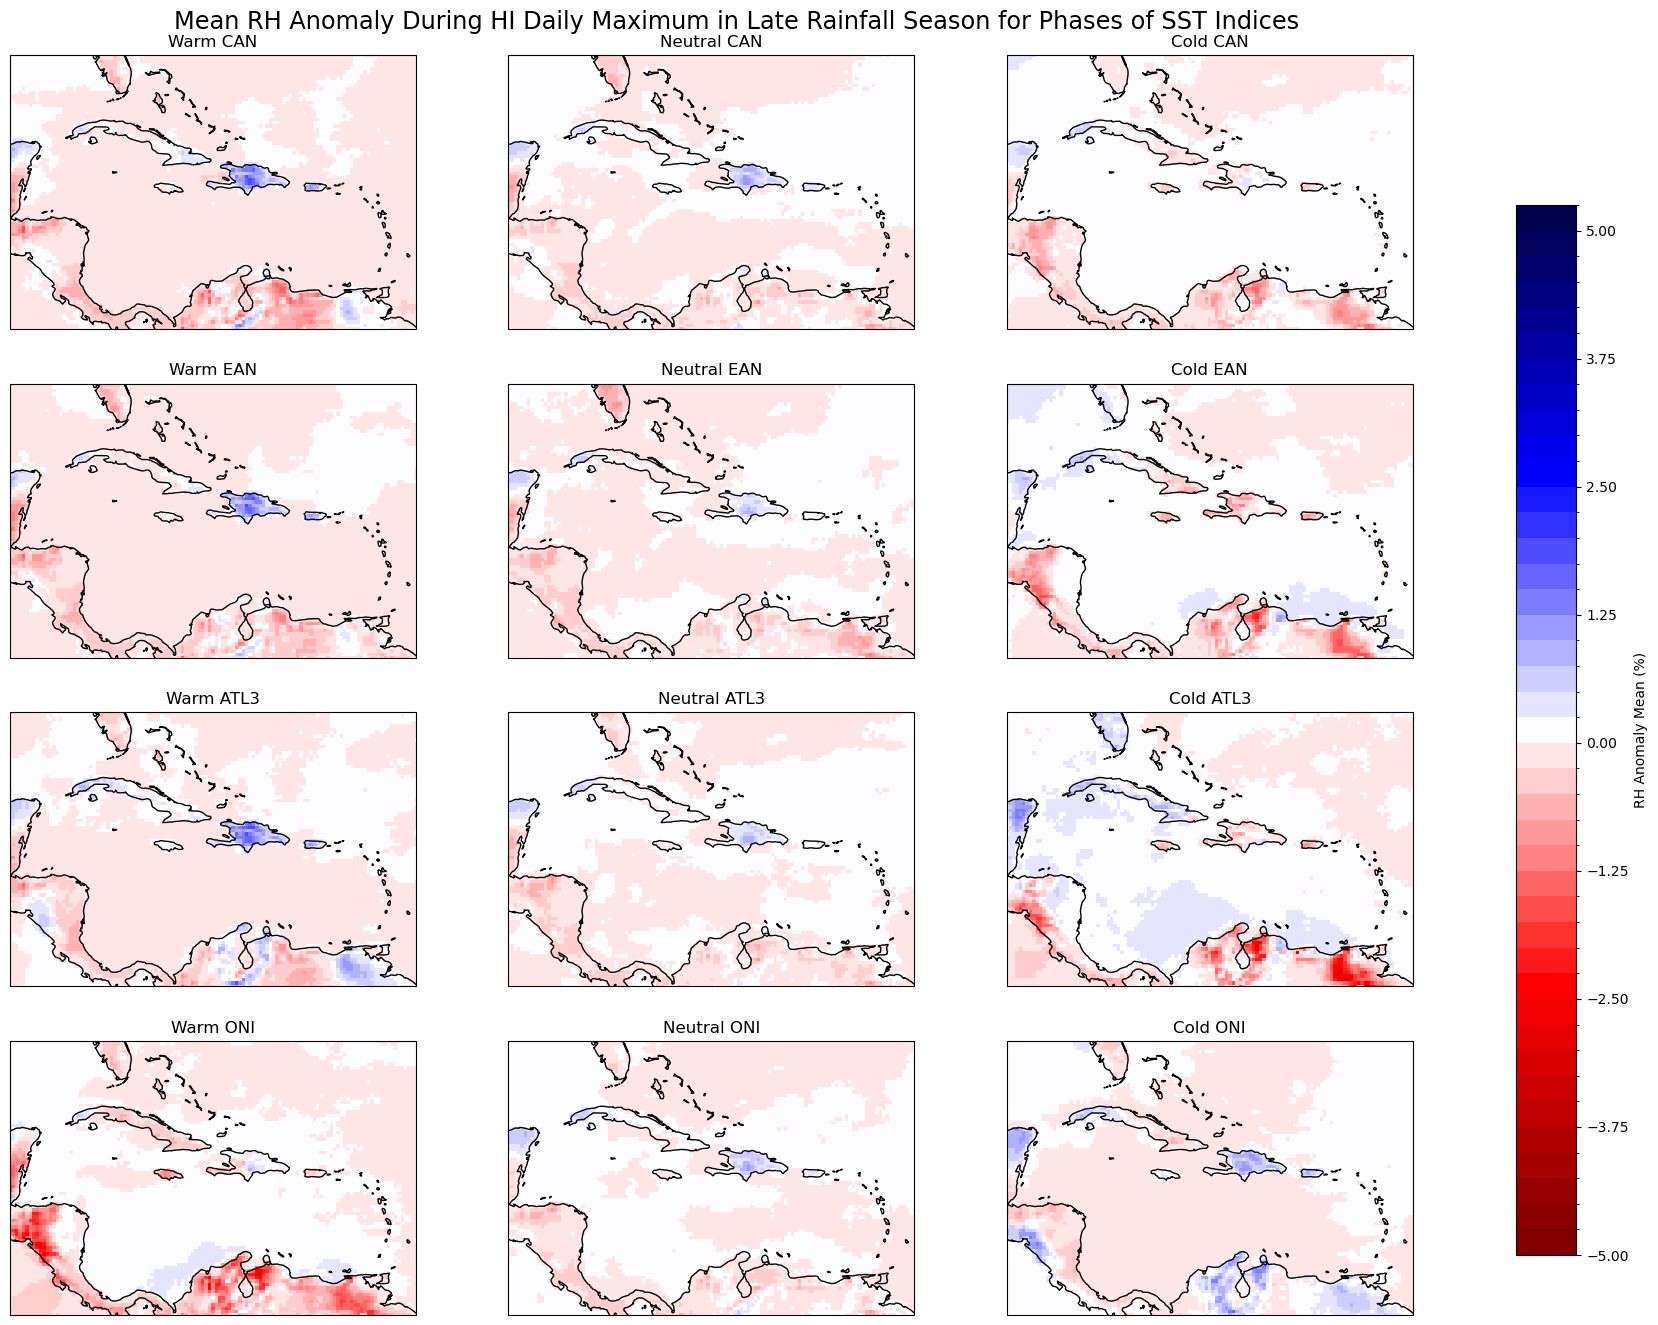

In [121]:
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(20, 15), sharex=True, sharey=True, subplot_kw={'projection': ccrs.PlateCarree()},)

flat_axes = axes.flatten()

for ax_i, da in enumerate(LRS_RH_oan_me):
    ax = flat_axes[ax_i]
    ax.set_extent([da.longitude.min(), da.longitude.max(), da.latitude.min(), da.latitude.max()], crs=ccrs.PlateCarree())
    
    da.plot(ax=ax, x='longitude', y='latitude', add_colorbar=False, levels=np.arange(-5, 5.5, 0.25), transform=ccrs.PlateCarree(), colors='seismic_r')
    
    ax.set_title(da.name)
    ax.coastlines(transform=ccrs.PlateCarree())

cax = fig.add_axes([0.89, 0.15, 0.03, 0.7])
fig.colorbar(axes.flat[0].collections[0],cax=cax, label='RH Anomaly Mean (%)', orientation='vertical', extend='neither')
plt.subplots_adjust(wspace=0.1, right=0.85, top=0.95)
plt.suptitle('Mean RH Anomaly During HI Daily Maximum in Late Rainfall Season for Phases of SST Indices', fontsize='xx-large')
plt.show()

### T

In [117]:
LRS_T_oan_me = []
for i in LRS_T_oan:
    LRS_T_oan_me.append(i.mean('time'))

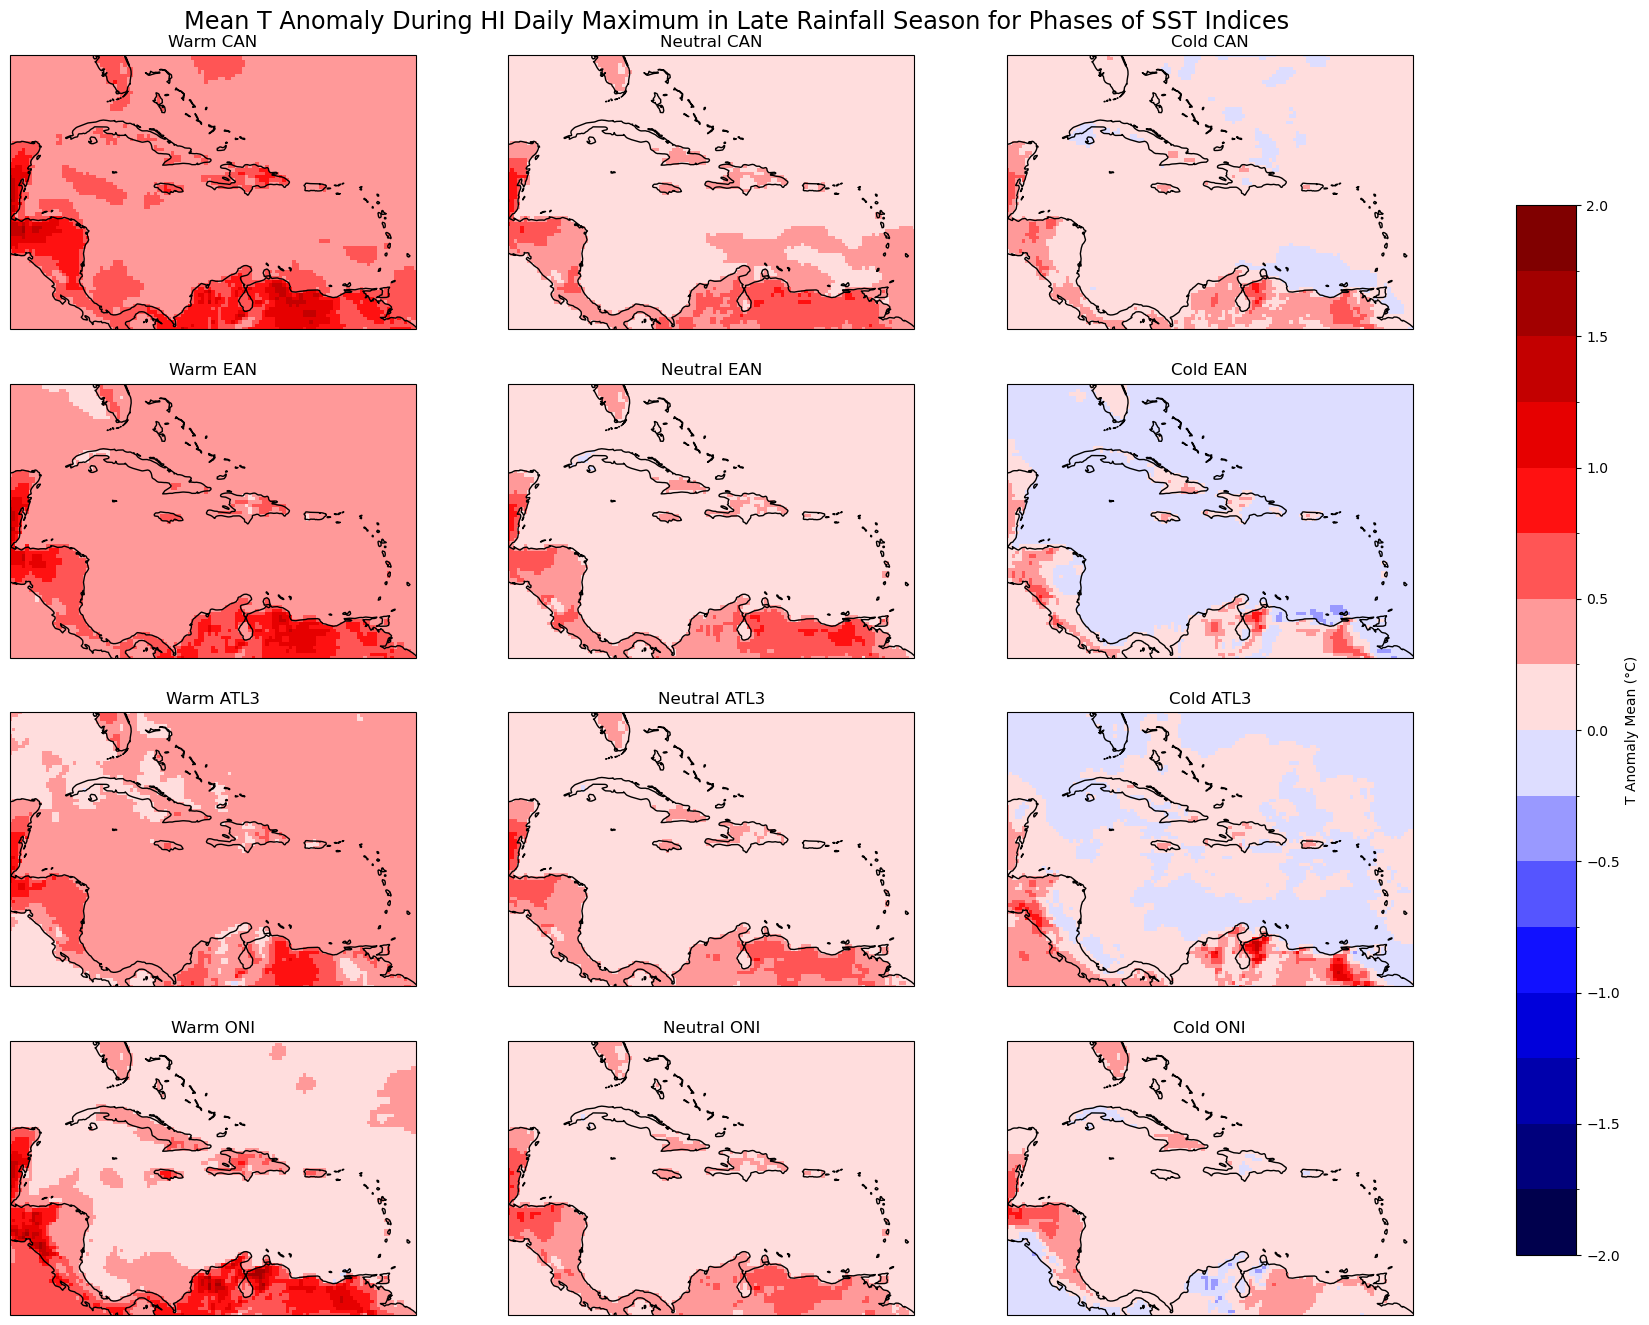

In [156]:
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(20, 15), sharex=True, sharey=True, subplot_kw={'projection': ccrs.PlateCarree()},)

flat_axes = axes.flatten()

for ax_i, da in enumerate(LRS_T_oan_me):
    ax = flat_axes[ax_i]
    ax.set_extent([da.longitude.min(), da.longitude.max(), da.latitude.min(), da.latitude.max()], crs=ccrs.PlateCarree())
    
    da.plot(ax=ax, x='longitude', y='latitude', add_colorbar=False, levels=np.arange(-2, 2.25, 0.25), transform=ccrs.PlateCarree(), colors='seismic')
    
    ax.set_title(da.name)
    ax.coastlines(transform=ccrs.PlateCarree())

cax = fig.add_axes([0.89, 0.15, 0.03, 0.7])
fig.colorbar(axes.flat[0].collections[0],cax=cax, label='T Anomaly Mean (°C)', orientation='vertical', extend='neither')
plt.subplots_adjust(wspace=0.1, right=0.85, top=0.95)
plt.suptitle('Mean T Anomaly During HI Daily Maximum in Late Rainfall Season for Phases of SST Indices', fontsize='xx-large')
plt.show()

## Significance filtered